# Home Credit Final Research Report

This notebook is a final narrative report for dataset-level research review. It intentionally keeps logic in `credit_risk_fs.reporting.notebook_report` and uses the notebook only for loading, display, and interpretation.


In [15]:
from pathlib import Path
import sys

if not Path('_legacy_shim.py').exists():
    candidate_root = Path.cwd().resolve().parents[1]
    if str(candidate_root) not in sys.path:
        sys.path.insert(0, str(candidate_root))

from IPython.display import Markdown, display

from credit_risk_fs.reporting.notebook_report import (
    load_best_runs,
    load_dataset_report_inputs,
    load_final_comparison,
    load_run_artifacts,
    plot_bad_rate_by_time,
    plot_dev_oot_split_diagnostics,
    plot_drift_vs_performance,
    plot_metric_leaderboard,
    plot_observation_count_by_time,
    plot_runtime_tradeoff,
    plot_semantic_coverage,
    plot_stability_vs_performance,
    summarize_clip_validation_placeholder,
    summarize_dataset_findings,
    summarize_split_rationale,
)

dataset_name = 'homecredit'
inputs = load_dataset_report_inputs(dataset_name)
final_df = load_final_comparison(dataset_name)
findings = summarize_dataset_findings(dataset_name)
clip_placeholder = summarize_clip_validation_placeholder(dataset_name)


## Research Question and Dataset Role

The research question is whether LLM-based metadata screening is useful as a first-stage feature-selection helper for credit scoring. Home Credit is the primary benchmark dataset in the repository. LR and CatBoost are evaluation vehicles rather than the core research contribution. Calibration, stacking, deployment logic, and any CLIP-style method implementation are out of scope in this report.


## Dataset Snapshot

The snapshot below is intended to anchor the rest of the report around the actual split, feature budget, and completed-run footprint rather than around isolated metrics.


In [16]:
if inputs['warnings']:
    display(Markdown('**Warnings and incomplete sections**'))
    for warning in inputs['warnings']:
        display(Markdown(f'- {warning}'))

display(inputs['snapshot'])


**Warnings and incomplete sections**

- Home Credit split diagnostics use application_train plus previous_application recency only, because no saved processed modeling table exists under data/homecredit/processed.

,dataset_name,dataset_role,DEV_rows,OOT_rows,DEV_bad_rate,OOT_bad_rate,time_column,DEV_window,OOT_window,engineered_candidate_features,encoded_or_modeling_features_if_available,LR_feature_budget,CatBoost_feature_budget,completed_runs,failed_runs
0,Home Credit,primary benchmark,99092,120053,0.0793,0.089,recent_decision,"[-600, -240)","[-240, 0]",529.0,NaN,20.0,40.0,16,0


## DEV/OOT Split Rationale

This section is mandatory because the research claim depends on realistic future-period validation rather than on random holdout performance.


The split is time-based rather than random. DEV is the older window used for cross-validation, feature selection, and model fitting, while OOT is the newer holdout used only for final evaluation. The window choice is justified by observation counts and target-rate behavior across time, with the goal of keeping both periods large enough for comparison without leaking future information into selector or model tuning. OOT bad rate is reported only to justify the validation setup; it is not used to tune feature selection or hyperparameters. For Home Credit, DEV uses relative days from -600 inclusive to -240 exclusive, and OOT uses -240 inclusive to 0 inclusive. This yields 99,092 DEV rows and 120,053 OOT rows, with bad rates of 0.0793 and 0.0890; the OOT minus DEV difference is 0.0097. That framing preserves an older development period and a more recent out-of-time period for realistic future-period validation.

,dataset,dataset_display_name,time_column,DEV_start,DEV_end,OOT_start,OOT_end,DEV_window,OOT_window,DEV_rows,...,OOT_bad_rate,bad_rate_difference,OOT_DEV_row_ratio,dropped_older_rows,dropped_missing_time_rows,source_row_count,DEV_issue_date_start,DEV_issue_date_end,OOT_issue_date_start,OOT_issue_date_end
0,homecredit,Home Credit,recent_decision,-600,-240,-240,0,"[-600, -240)","[-240, 0]",99092,...,0.089,0.0097,1.2115,71912,16454,307511,None,None,None,None


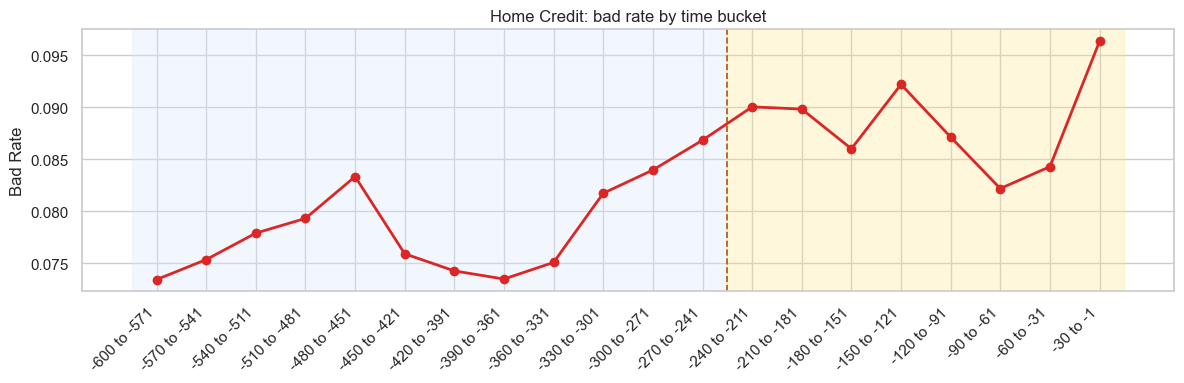

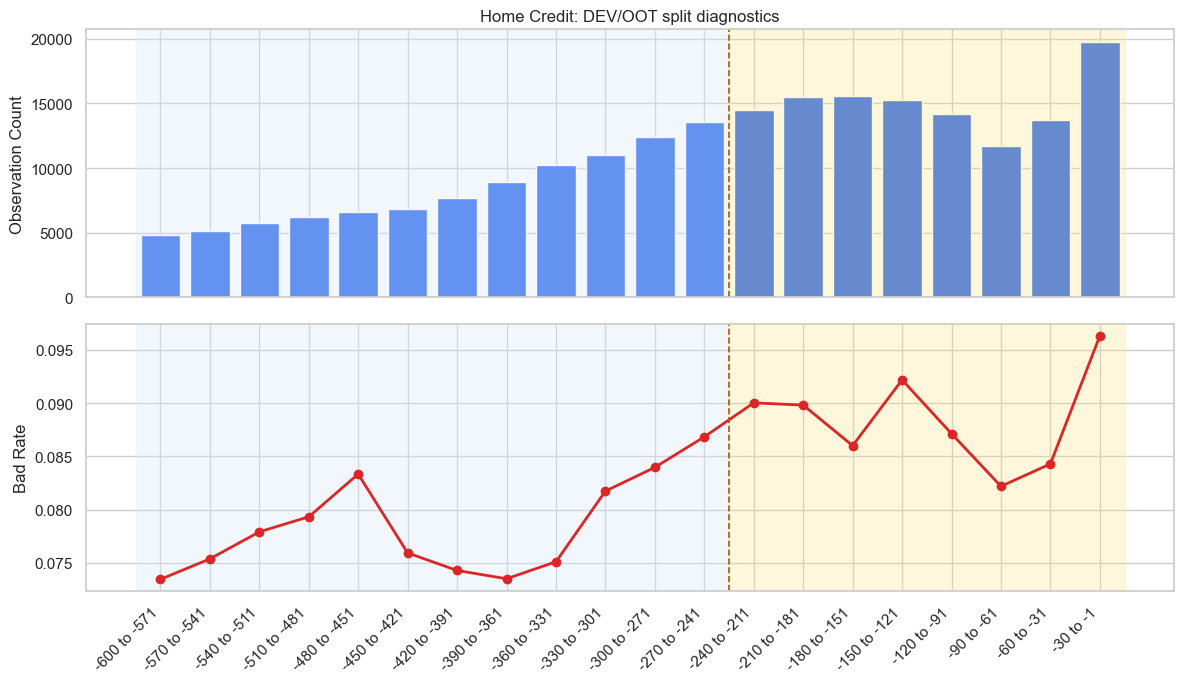

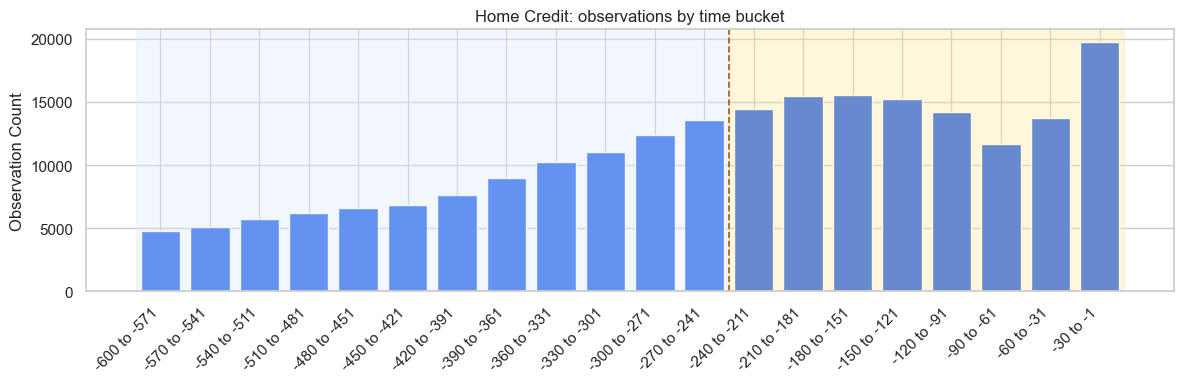

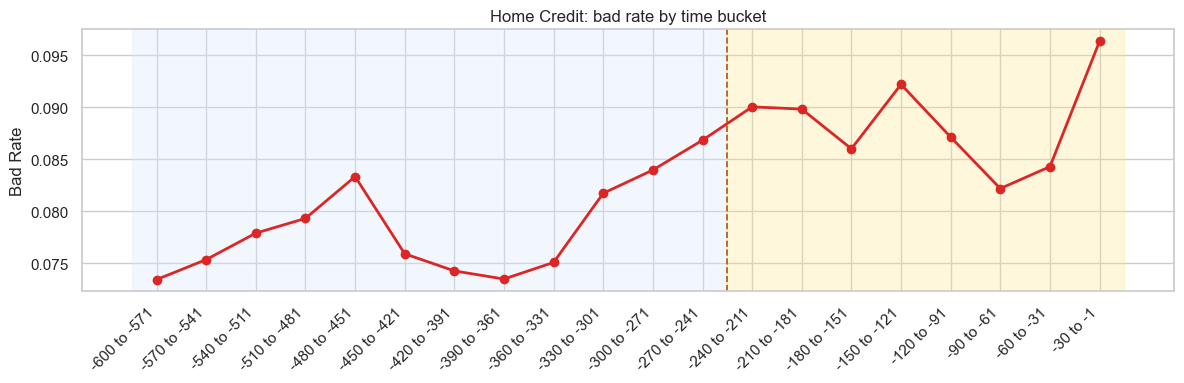

In [17]:
display(Markdown(summarize_split_rationale(dataset_name)))
display(inputs['split_summary'])
plot_dev_oot_split_diagnostics(dataset_name)
plot_observation_count_by_time(dataset_name)
plot_bad_rate_by_time(dataset_name)


## Experiment Matrix Overview

The matrix should be read as a controlled comparison across statistical baselines, LLM-only screening, and hybrid first-stage screening rather than as a search for a single universally dominant selector.


In [18]:
display(inputs['matrix_overview'])
display(Markdown(findings['experiment_matrix_markdown']))


,dataset,models,selectors,feature_budgets,completed_run_count,failed_run_count
0,homecredit,"catboost, lr","mrmr, boruta, pca, domain_rule_baseline, llm, ...","20, 40",16,0


The matrix compares statistical baselines, pure LLM screening, and LLM-then-statistical hybrids under the same DEV/OOT protocol. The target comparison is therefore about first-stage screening utility, not about replacing the downstream LR or CatBoost evaluation vehicles.

## Topline Performance Comparison

This section stays concise on purpose. The point is to identify where the strongest OOT results sit and whether the gap over the best baseline is meaningful or only marginal.


,model,selector,experiment_type,oot_auc,oot_gini,oot_ks,lift_at_10,selected_feature_count,runtime_seconds,model_score_psi
0,lr,stable_core_llm_fill,hybrid,0.7489,0.4977,0.3688,3.1033,20.0,1475.4382,0.0050
1,lr,mrmr,statistical,0.7457,0.4914,0.3618,3.0958,20.0,728.3589,0.0065
2,lr,llm,llm,0.7400,0.4799,0.3573,3.0322,20.0,47.6981,0.0066
3,lr,llm_then_mrmr,hybrid,0.7381,0.4762,0.3537,2.9508,20.0,85.9960,0.0038
4,lr,domain_rule_baseline,statistical,0.7249,0.4498,0.3346,2.8713,20.0,17.8531,0.0112
5,lr,pca,statistical,0.6729,0.3458,0.2597,2.2697,20.0,17.5848,0.0291
6,lr,llm_then_boruta,hybrid,0.6488,0.2976,0.2151,2.1584,20.0,248.9272,0.0009
7,lr,boruta,statistical,0.6306,0.2612,0.1874,2.0358,20.0,1011.1587,0.0024
8,catboost,stable_core_llm_fill,hybrid,0.7683,0.5367,0.4022,3.4270,40.0,4111.4814,0.0076
9,catboost,mrmr,statistical,0.7668,0.5337,0.4017,3.4036,40.0,960.1895,0.0102


Home Credit remains the main benchmark, and the topline leaderboard is mixed rather than one-sided. For LR, `stable_core_llm_fill` is best on OOT AUC (0.7489); for CatBoost, `stable_core_llm_fill` leads at 0.7683. The strongest non-LLM baseline is `mrmr` at 0.7668. The OOT gains of the best LLM-family method over the best baseline are small: 0.0032 AUC for LR and 0.0015 for CatBoost. Paired-fold CV deltas versus the mRMR baseline were negative (mean AUC delta -0.0038, 95% CI -0.0063 to -0.0013).

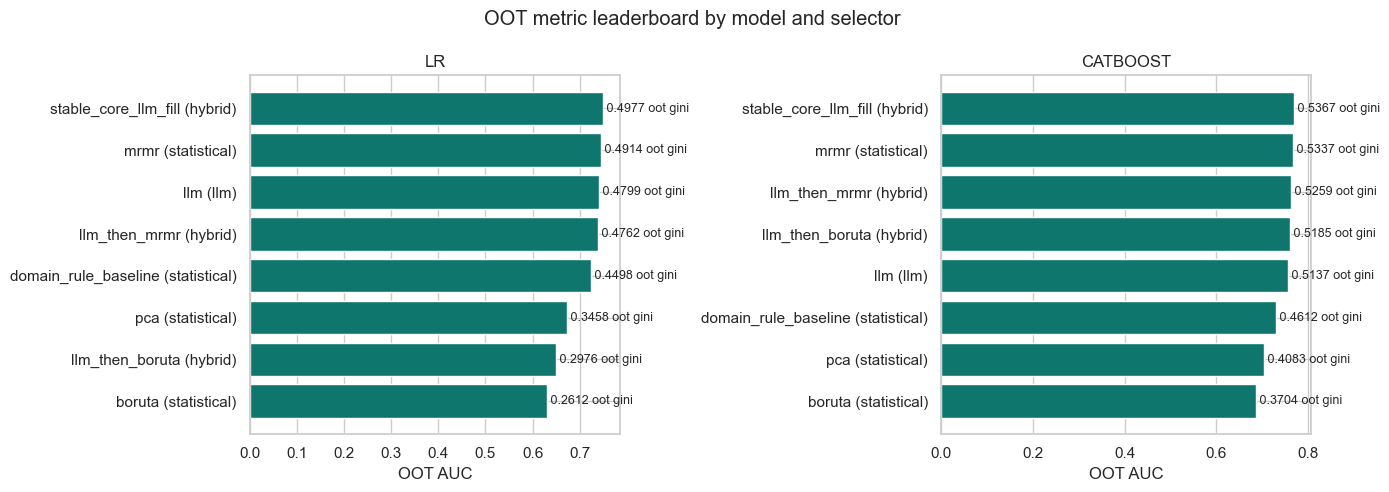

In [19]:
leaderboard_columns = [
    'model',
    'selector',
    'experiment_type',
    'oot_auc',
    'oot_gini',
    'oot_ks',
    'lift_at_10',
    'selected_feature_count',
    'runtime_seconds',
    'model_score_psi',
]
display(final_df[leaderboard_columns])
plot_metric_leaderboard(final_df)
display(Markdown(findings['topline_markdown']))


## Stability Review

Exact feature-set repeatability and semantic stability should be treated separately. Strong OOT performance is useful only if the selected set is not erratic across folds.


,dataset_name,model,selector,experiment_type,nogueira_stability,kuncheva_stability,mean_pairwise_jaccard,semantic_group_jaccard,stable_feature_count_80,stable_feature_ratio_80,stable_semantic_group_count_80,semantic_group_stable_ratio_80,spearman_rank_stability_mean,kendall_rank_stability_mean,rbo_rank_stability_mean
0,homecredit,catboost,domain_rule_baseline,statistical,1.0000,1.0000,1.0000,1.0000,40.0,1.000,2.0,1.0000,1.0000,1.0000,NaN
1,homecredit,catboost,pca,statistical,1.0000,1.0000,1.0000,1.0000,40.0,1.000,1.0,1.0000,1.0000,1.0000,NaN
2,homecredit,catboost,mrmr,statistical,0.7296,0.7296,0.6037,0.9400,29.0,0.725,9.0,1.0000,0.6908,0.4825,NaN
3,homecredit,catboost,stable_core_llm_fill,hybrid,0.7025,0.7025,0.5725,0.8291,28.0,0.700,8.0,0.8889,0.1631,-0.0305,NaN
4,homecredit,catboost,boruta,statistical,0.5646,0.5646,0.4529,0.6315,25.0,0.625,8.0,1.1429,0.2292,0.1795,NaN
5,homecredit,catboost,llm_then_boruta,hybrid,0.4402,0.4402,0.3247,0.7367,15.0,0.375,6.0,0.8571,0.1631,-0.0305,NaN
6,homecredit,catboost,llm,llm,0.4294,0.4294,0.3149,0.7473,18.0,0.450,7.0,0.8750,0.1631,-0.0305,NaN
7,homecredit,catboost,llm_then_mrmr,hybrid,0.4077,0.4077,0.2966,0.8625,13.0,0.325,9.0,1.0000,0.1631,-0.0305,NaN
8,homecredit,lr,domain_rule_baseline,statistical,1.0000,1.0000,1.0000,1.0000,20.0,1.000,2.0,1.0000,1.0000,1.0000,NaN
9,homecredit,lr,pca,statistical,1.0000,1.0000,1.0000,1.0000,20.0,1.000,1.0,1.0000,1.0000,1.0000,NaN


Stability does not support a simple 'LLM dominates' claim. The highest Nogueira stability belongs to `pca` on `catboost` at 1.0000. Deterministic selectors such as PCA and the domain baseline show perfect or near-perfect repeatability, but that exact repeatability is not sufficient when OOT discrimination is weak. The stable-core hybrid improves the balance between exact feature stability and semantic stability more than the pure LLM selector.

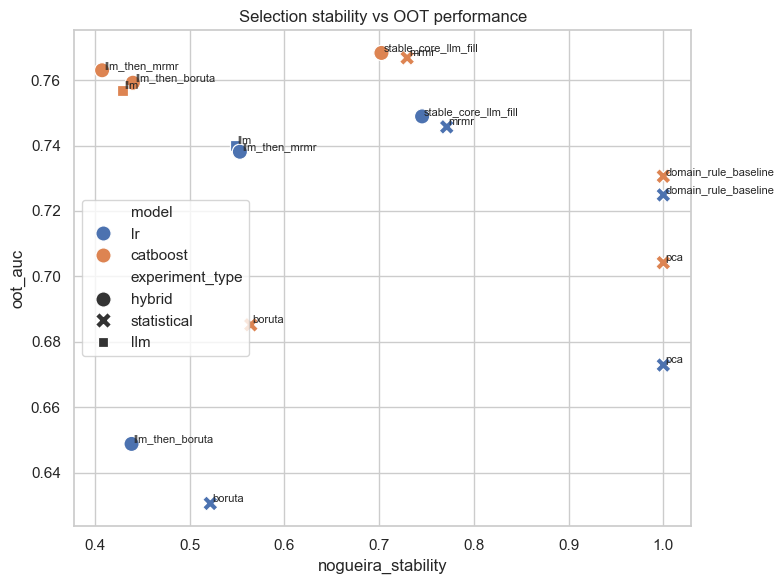

In [20]:
display(inputs['stability_table'])
plot_stability_vs_performance(inputs['stability_table'], final_df)
display(Markdown(findings['stability_markdown']))


## Drift and Robustness Review

OOT PSI is evaluation-only in this report. It is not a tuning signal and should be read as a robustness check on the selected feature set and resulting model scores.


,model,selector,experiment_type,selected_feature_psi_mean,selected_feature_psi_max,model_score_psi
0,catboost,llm,llm,0.0022,0.0207,0.0054
1,catboost,domain_rule_baseline,statistical,0.0033,0.0207,0.0054
2,catboost,boruta,statistical,0.0062,0.0223,0.0032
3,catboost,llm_then_mrmr,hybrid,0.0108,0.0579,0.0083
4,catboost,stable_core_llm_fill,hybrid,0.0121,0.0935,0.0076
5,catboost,llm_then_boruta,hybrid,0.0133,0.0822,0.0094
6,catboost,mrmr,statistical,0.0187,0.1670,0.0102
7,catboost,pca,statistical,0.0292,0.1217,0.0382
8,lr,llm,llm,0.0015,0.0207,0.0066
9,lr,domain_rule_baseline,statistical,0.0030,0.0207,0.0112


High OOT performance on Home Credit is not concentrated in the highest-drift methods. The lowest-drift top run in the table is `llm` on `lr` with feature PSI mean 0.0015. PCA deserves specific caution: its OOT scores are weak and its drift indicators are materially worse than the better-performing selectors. OOT PSI is used only for evaluation; it is not a training or selection signal.

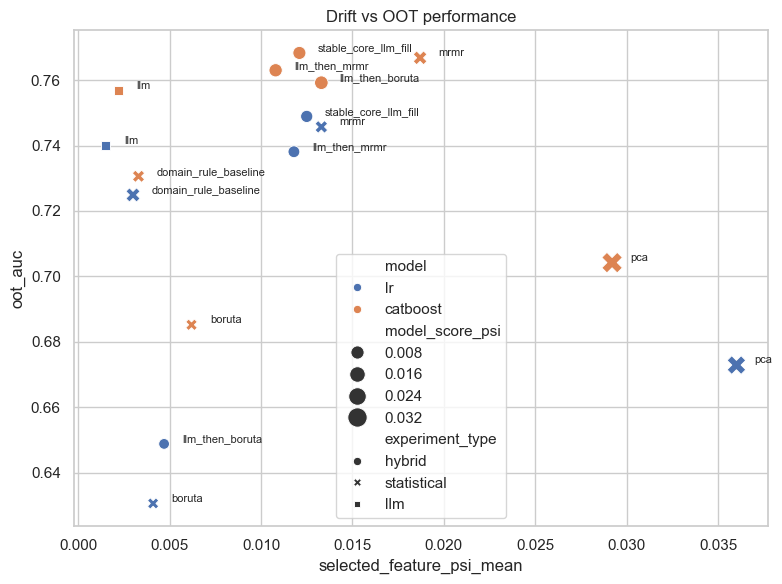

In [21]:
drift_columns = [
    'model',
    'selector',
    'experiment_type',
    'selected_feature_psi_mean',
    'selected_feature_psi_max',
    'model_score_psi',
]
display(inputs['drift_table'][drift_columns])
plot_drift_vs_performance(inputs['drift_table'], final_df)
display(Markdown(findings['drift_markdown']))


## Semantic Coverage Review

The semantic-coverage section is meant to check whether LLM-based screening preserves a broader business-facing view of credit-risk evidence or simply re-creates narrow statistical patterns.


,model,selector,experiment_type,semantic_group_count,dominant_group_ratio,dominant_group
0,catboost,boruta,statistical,4,0.450,bureau_credit_history
1,catboost,domain_rule_baseline,statistical,2,0.925,bureau_debt
2,catboost,llm,llm,8,0.400,bureau_credit_history
3,catboost,llm_then_boruta,hybrid,9,0.275,bureau_credit_history
4,catboost,llm_then_mrmr,hybrid,10,0.250,installment_repayment_behavior
5,catboost,mrmr,statistical,10,0.225,installment_repayment_behavior
6,catboost,pca,statistical,1,1.000,other
7,catboost,stable_core_llm_fill,hybrid,10,0.200,bureau_credit_history
8,lr,boruta,statistical,3,0.500,bureau_debt
9,lr,domain_rule_baseline,statistical,2,0.850,bureau_debt


Semantic coverage is broader for mRMR and the better LLM hybrids than for PCA or the domain baseline. The broadest selector/model combination in the saved coverage table is `mrmr` on `catboost` with 10 distinct semantic groups. That supports the narrower claim that LLM screening can help preserve business-relevant feature families, but it does not remove the need for statistical discipline.

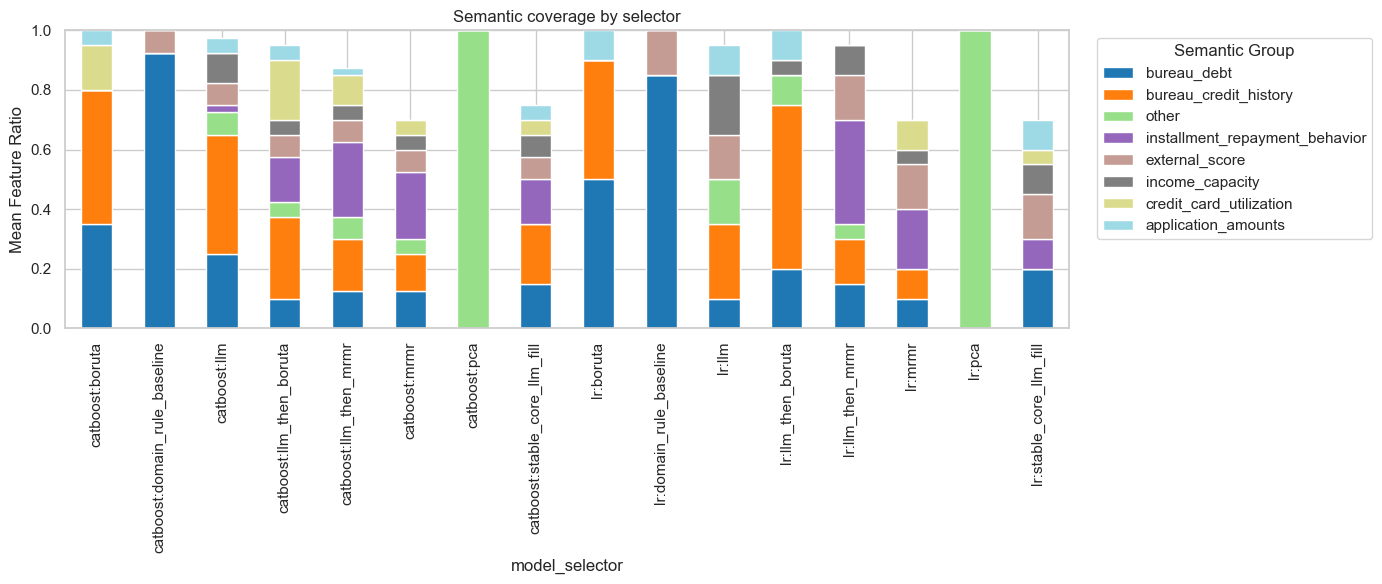

In [22]:
display(inputs['semantic_summary'])
plot_semantic_coverage(inputs['semantic_coverage_table'])
display(Markdown(findings['semantic_markdown']))


## Efficiency Tradeoff

A useful first-stage screener should be judged on runtime, selected-feature compactness, and incremental performance together, not on headline AUC alone.


,model,selector,oot_auc,oot_gini,runtime_seconds,selected_feature_count,feature_reduction_ratio,oot_auc_per_feature
0,lr,stable_core_llm_fill,0.7489,0.4977,1475.4382,20.0,0.9622,0.0374
1,lr,mrmr,0.7457,0.4914,728.3589,20.0,0.9622,0.0373
2,lr,llm,0.7400,0.4799,47.6981,20.0,0.9622,0.0370
3,lr,llm_then_mrmr,0.7381,0.4762,85.9960,20.0,0.9622,0.0369
4,lr,domain_rule_baseline,0.7249,0.4498,17.8531,20.0,0.9622,0.0362
5,lr,pca,0.6729,0.3458,17.5848,20.0,0.9622,0.0336
6,lr,llm_then_boruta,0.6488,0.2976,248.9272,20.0,0.9622,0.0324
7,lr,boruta,0.6306,0.2612,1011.1587,20.0,0.9622,0.0315
8,catboost,stable_core_llm_fill,0.7683,0.5367,4111.4814,40.0,0.9244,0.0192
9,catboost,mrmr,0.7668,0.5337,960.1895,40.0,0.9244,0.0192


,run_id,model,selector,llm_calls_actually_made,llm_cache_hits,llm_total_tokens
0,catboost_hybrid_llm_then_boruta_159b47a7bfa0,catboost,llm_then_boruta,0,6,0
1,catboost_hybrid_llm_then_mrmr_87fbcccf4952,catboost,llm_then_mrmr,0,6,0
2,catboost_hybrid_stable_core_llm_fill_8993eae5a4f7,catboost,stable_core_llm_fill,0,6,0
3,catboost_llm_llm_d54c966a1d6e,catboost,llm,0,6,0
4,catboost_statistical_boruta_486630bccdb9,catboost,boruta,0,0,0
5,catboost_statistical_domain_rule_baseline_b0a5...,catboost,domain_rule_baseline,0,0,0
6,catboost_statistical_mrmr_3858b721e537,catboost,mrmr,0,0,0
7,catboost_statistical_pca_26fcebfff558,catboost,pca,0,0,0
8,lr_hybrid_llm_then_boruta_9ceedb78b89f,lr,llm_then_boruta,0,6,0
9,lr_hybrid_llm_then_mrmr_f69e1a0cffc2,lr,llm_then_mrmr,0,6,0


Efficiency tradeoffs matter. Boruta is the slowest weak baseline, while the pure LLM LR run is cheap in wall-clock terms and reasonably competitive. Shared cache usage is already visible in the current artifacts: 48 cache hits are recorded and 0 tokens were effectively spent in the saved summaries, which limits repeated LLM cost for reused metadata rankings.

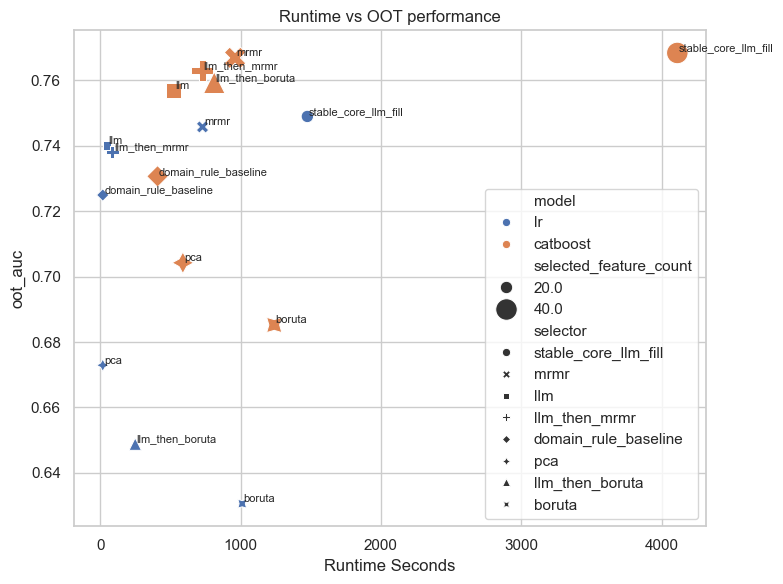

In [23]:
efficiency_columns = [
    'model',
    'selector',
    'oot_auc',
    'oot_gini',
    'runtime_seconds',
    'selected_feature_count',
    'feature_reduction_ratio',
    'oot_auc_per_feature',
]
llm_summary_columns = [
    'run_id',
    'model',
    'selector',
    'llm_calls_actually_made',
    'llm_cache_hits',
    'llm_total_tokens',
]
display(final_df[efficiency_columns])
display(inputs['llm_call_summary'][llm_summary_columns])
plot_runtime_tradeoff(final_df)
display(Markdown(findings['efficiency_markdown']))


## Best Runs Deep Dive

Only a few runs are surfaced here. The goal is to review representative high-value cases rather than dump full feature lists.


In [24]:
best_runs = load_best_runs(dataset_name)
display(best_runs)

for run_id in best_runs['run_id']:
    artifacts = load_run_artifacts(dataset_name, run_id)
    display(Markdown(f'### {run_id}'))
    if not artifacts['summary_table'].empty:
        summary_columns = [
            'model_name',
            'selector_name',
            'cv_auc_mean',
            'cv_auc_std',
            'oot_auc',
            'oot_gini',
            'oot_ks',
            'runtime_seconds',
        ]
        display(artifacts['summary_table'][summary_columns])
    display(artifacts['semantic_group_summary'].head(5))
    display(artifacts['selected_features'][['feature_name', 'semantic_group', 'rank']].head(10))
    display(artifacts['cv_results'][['fold', 'auc', 'gini', 'ks', 'selected_features']].head(5))
    display(artifacts['oot_results'])


,analysis_label,run_id,model,selector,experiment_type,OOT_AUC,OOT_Gini,OOT_KS,CV_AUC_mean,CV_AUC_std,selected_feature_count,top_features,top_semantic_groups,fold_behavior,why_it_matters
0,best LR run,lr_hybrid_stable_core_llm_fill_1ddd0142e614,lr,stable_core_llm_fill,hybrid,0.7489,0.4977,0.3688,0.7317,0.0144,20.0,"EXT_SOURCE_2, EXT_SOURCE_3, PREV_INTEREST_ESTI...","bureau_debt (4), previous_application_behavior...",CV AUC 0.7317 +/- 0.0144,highest OOT leaderboard entry for this slice
1,best CatBoost run,catboost_hybrid_stable_core_llm_fill_8993eae5a4f7,catboost,stable_core_llm_fill,hybrid,0.7683,0.5367,0.4022,0.7480,0.0165,40.0,"EXT_SOURCE_2, EXT_SOURCE_3, PREV_INTEREST_ESTI...","bureau_credit_history (8), bureau_debt (6), in...",CV AUC 0.7480 +/- 0.0165,highest OOT leaderboard entry for this slice
2,strongest non-LLM baseline,catboost_statistical_mrmr_3858b721e537,catboost,mrmr,statistical,0.7668,0.5337,0.4017,0.7518,0.0143,40.0,"EXT_SOURCE_2, EXT_SOURCE_3, PREV_INTEREST_ESTI...","installment_repayment_behavior (9), previous_a...",CV AUC 0.7518 +/- 0.0143,reference baseline for non-LLM comparison


### lr_hybrid_stable_core_llm_fill_1ddd0142e614

,model_name,selector_name,cv_auc_mean,cv_auc_std,oot_auc,oot_gini,oot_ks,runtime_seconds
0,lr,stable_core_llm_fill,0.7317,0.0144,0.7489,0.4977,0.3688,1475.4382


,semantic_group,feature_count,feature_ratio
1,bureau_debt,4,0.20
8,previous_application_behavior,3,0.15
5,external_score,3,0.15
0,application_amounts,2,0.10
4,demographic_time_variables,2,0.10


,feature_name,semantic_group,rank
0,EXT_SOURCE_2,external_score,1
1,EXT_SOURCE_3,external_score,2
2,PREV_INTEREST_ESTIMATE_MAX,previous_application_behavior,3
3,EXT_SOURCE_1,external_score,4
4,DAYS_EMPLOYED,income_capacity,5
5,BURO_DEBT_CREDIT_DIFF_MIN,bureau_debt,6
6,INSTAL_IS_LATE_MEAN,installment_repayment_behavior,7
7,INSTAL_PAYMENT_DIFF_MEAN,installment_repayment_behavior,8
8,PREV_INTEREST_ESTIMATE_VAR,previous_application_behavior,9
9,DAYS_REGISTRATION,demographic_time_variables,10


...

,model_name,selector_name,cv_auc_mean,cv_auc_std,oot_auc,oot_gini,oot_ks,runtime_seconds
0,catboost,mrmr,0.7518,0.0143,0.7668,0.5337,0.4017,960.1895


,semantic_group,feature_count,feature_ratio
7,installment_repayment_behavior,9,0.225
9,previous_application_behavior,6,0.150
1,bureau_debt,5,0.125
0,bureau_credit_history,5,0.125
4,demographic_time_variables,4,0.100


,feature_name,semantic_group,rank
0,EXT_SOURCE_2,external_score,1
1,EXT_SOURCE_3,external_score,2
2,PREV_INTEREST_ESTIMATE_MAX,previous_application_behavior,3
3,EXT_SOURCE_1,external_score,4
4,BURO_DEBT_CREDIT_DIFF_MIN,bureau_debt,5
5,DAYS_EMPLOYED,income_capacity,6
6,INSTAL_IS_LATE_MEAN,installment_repayment_behavior,7
7,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,credit_card_utilization,8
8,DAYS_REGISTRATION,demographic_time_variables,9
9,POS_SK_DPD_DEF_MEAN,delinquency_behavior,10


,fold,auc,gini,ks,selected_features
0,1,0.7354,0.4708,0.3601,40.0
1,2,0.7378,0.4756,0.3544,40.0
2,3,0.7655,0.5310,0.4033,40.0
3,4,0.7638,0.5276,0.4038,40.0
4,5,0.7564,0.5128,0.3711,40.0


,gini,auc,ks,ks_threshold,decision_threshold,tn,fp,fn,tp,precision,...,selected_feature_psi_mean,selected_feature_psi_max,selected_feature_psi_median,selected_feature_psi_high_drift_ratio,selected_feature_psi_moderate_or_high_drift_ratio,model_score_psi,lift_at_10,bad_rate_capture_at_10,lift_at_20,bad_rate_capture_at_20
0,0.5337,0.7668,0.4017,0.3865,0.5212,91541,17824,5067,5621,0.2398,...,0.0187,0.167,0.006,0.0,0.025,0.0102,3.4036,0.3404,2.6679,0.5336


## Failure Cases and Surprises

This section is intentionally compact. It is here to record weak selectors, ambiguous wins, and dataset-specific caveats that should survive into the written research discussion.


In [25]:
failure_rows = final_df[final_df['selector'].isin(['boruta', 'pca', 'domain_rule_baseline', 'llm', 'stable_core_llm_fill', 'mrmr'])]
display(failure_rows[['model', 'selector', 'oot_auc', 'oot_gini', 'nogueira_stability', 'selected_feature_psi_mean', 'runtime_seconds']])
display(Markdown(findings['failure_markdown']))


,model,selector,oot_auc,oot_gini,nogueira_stability,selected_feature_psi_mean,runtime_seconds
0,lr,stable_core_llm_fill,0.7489,0.4977,0.7454,0.0125,1475.4382
1,lr,mrmr,0.7457,0.4914,0.7714,0.0133,728.3589
2,lr,llm,0.7400,0.4799,0.5479,0.0015,47.6981
4,lr,domain_rule_baseline,0.7249,0.4498,1.0000,0.0030,17.8531
5,lr,pca,0.6729,0.3458,1.0000,0.0360,17.5848
7,lr,boruta,0.6306,0.2612,0.5219,0.0041,1011.1587
8,catboost,stable_core_llm_fill,0.7683,0.5367,0.7025,0.0121,4111.4814
9,catboost,mrmr,0.7668,0.5337,0.7296,0.0187,960.1895
12,catboost,llm,0.7569,0.5137,0.4294,0.0022,520.9378
13,catboost,domain_rule_baseline,0.7306,0.4612,1.0000,0.0033,407.9447


The main failure cases are consistent. Boruta underperforms despite long runtime, PCA looks mechanically stable but not robust, and `llm_then_boruta` is clearly weaker than mRMR-based comparators. Home Credit still carries a manual-review caveat: auxiliary tables must be semantically confirmed as historical or as-of the application date, otherwise temporal meaning can be overstated.

## Conclusions for This Dataset

The conclusion should stay disciplined: the relevant question is whether LLM screening is useful as a first-stage helper, not whether it replaces all statistical selectors.


In [26]:
display(Markdown(findings['conclusion_markdown']))


On Home Credit, the evidence supports a careful claim: LLM screening is useful as a first-stage helper, especially in the stable-core hybrid, but the improvement over mRMR is marginal rather than dominant. The strongest carry-forward method for cross-dataset discussion is `stable_core_llm_fill`, with mRMR as the non-LLM reference. The evidence is mixed across performance, stability, drift, and semantic coverage rather than coming from a single decisive metric.

## Future Extension: CLIP-Style Semantic-Statistical Feature Alignment

This is a placeholder section only. No CLIP-style modeling is implemented in this notebook or in the current reporting wrapper.


In [27]:
display(Markdown(clip_placeholder['summary']))
display(clip_placeholder['artifacts'])


This section is a reserved placeholder for future CLIP-style semantic-statistical feature alignment. It is not image CLIP and is not implemented here. The future method would align feature text and metadata with empirical feature behavior in a shared representation space, using DEV-only evidence and comparing the resulting screener against the current selectors under the same DEV/OOT protocol. OOT metrics must not be used for CLIP-style training or feature selection; they remain final evaluation only.

,planned_artifact,purpose,status,notes
0,feature_level_evidence.csv,one row per feature with semantic and empirica...,planned,input table for alignment and downstream audit
1,contrastive_pairs.csv,"positive, hard-negative, and easy-negative fea...",planned,pairs should be constructed from DEV-only evid...
2,clip_embedding_table.csv,learned feature embeddings and similarity to a...,planned,dual-encoder or contrastive feature-space output
3,clip_vs_llm_vs_mrmr_comparison.csv,compare the future CLIP-style screener against...,planned,must be evaluated under the same DEV/OOT protocol


## Next Actions

These are concrete follow-up items that can be taken after review without changing the current research scope.


In [28]:
display(Markdown(findings['next_actions_markdown']))


Concrete next steps: regenerate any missing aggregate tables before review, harden LLM cache-key lineage, add a feature-level evidence table for future semantic-statistical alignment work, verify Home Credit temporal as-of assumptions, keep the LendingClub raw-data leakage blacklist strict, and prepare future CLIP-style validation artifacts without training that method yet.